# Notebook 02 — Feature Engineering & Preprocessing
**Project:** Credit Card Fraud Detection 
 
**Stage:** Clean → Engineer → Select → Split → Balance  



---
## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # add project root to path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data.data_preprocessing  import DataPreprocessor
from src.features.build_features   import FeatureEngineer
from src.features.feature_selection import FeatureSelector
from src.visualization.eda_plots   import EDAVisualizer
from src.utils.config             import load_config

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

SAVE_DIR = "../reports/figures"
CFG_PATH = "../configs/data_config.yaml"

cfg    = load_config(CFG_PATH)
viz    = EDAVisualizer(save_dir=SAVE_DIR)
TARGET = cfg["data"]["target_column"]          # "Class"
DROP   = cfg["data"].get("drop_columns", [])   
RS     = cfg["project"]["random_state"]        # 42

print("Setup complete")
print(f"Target column : {TARGET}")
print(f"Drop columns  : {DROP}")
print(f"Random state  : {RS}")

Setup complete
Target column : Class
Drop columns  : []
Random state  : 42


---
## 1. Load Raw Snapshot



In [2]:
df_raw = pd.read_parquet("../data/interim/raw_snapshot.parquet")
print(f"Loaded raw snapshot: {df_raw.shape}")
print(f"Fraud rate: {df_raw[TARGET].mean():.4%}")
df_raw.head(3)

Loaded raw snapshot: (284807, 31)
Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0


---
## 2. Split FIRST — Before Any Fitting



In [3]:
test_size  = cfg["split"]["test_size"]   # 0.15
val_size   = cfg["split"]["val_size"]    # 0.15
stratify   = cfg["split"].get("stratify", True)

X_raw = df_raw.drop(columns=[TARGET] + DROP, errors="ignore")
y_raw = df_raw[TARGET]

# ── First cut: carve off test (15%) ──────────────────────────────
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_raw,
    test_size=test_size,
    random_state=RS,
    stratify=y_raw if stratify else None
)

# ── Second cut: carve val from remaining 85% ─────────────────────
# We want val = 15% of total
# val_ratio = 0.15 / (1.0 - 0.15) = 0.1765 of the remaining 85%
val_ratio = val_size / (1.0 - test_size)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    random_state=RS,
    stratify=y_temp if stratify else None
)

print("=== Split summary (BEFORE any fitting) ===")
print(f"  Train : {X_train_raw.shape}  | fraud: {y_train.sum():,} ({y_train.mean():.4%})")
print(f"  Val   : {X_val_raw.shape}  | fraud: {y_val.sum():,}   ({y_val.mean():.4%})")
print(f"  Test  : {X_test_raw.shape}  | fraud: {y_test.sum():,}   ({y_test.mean():.4%})")
print()
print("Verify: all three fraud rates should be ~0.173% (stratification check)")

=== Split summary (BEFORE any fitting) ===
  Train : (199364, 30)  | fraud: 344 (0.1725%)
  Val   : (42721, 30)  | fraud: 74   (0.1732%)
  Test  : (42722, 30)  | fraud: 74   (0.1732%)

Verify: all three fraud rates should be ~0.173% (stratification check)


### 2.1 Verify stratification worked

In [4]:
original_rate = df_raw[TARGET].mean()
print(f"Original fraud rate : {original_rate:.4%}")
print(f"Train fraud rate    : {y_train.mean():.4%}  ← should match")
print(f"Val fraud rate      : {y_val.mean():.4%}   ← should match")
print(f"Test fraud rate     : {y_test.mean():.4%}   ← should match")

# Build DataFrames for preprocessor (needs target column present)
train_raw_df = X_train_raw.copy()
train_raw_df[TARGET] = y_train.values

val_raw_df = X_val_raw.copy()
val_raw_df[TARGET] = y_val.values

test_raw_df = X_test_raw.copy()
test_raw_df[TARGET] = y_test.values

Original fraud rate : 0.1727%
Train fraud rate    : 0.1725%  ← should match
Val fraud rate      : 0.1732%   ← should match
Test fraud rate     : 0.1732%   ← should match


---
## 3. Data Preprocessing — Fit on Train Only


In [5]:
preprocessor = DataPreprocessor(config_path=CFG_PATH)

# FIT on training data only — learns statistics from train
train_clean = preprocessor.fit_transform(train_raw_df)

# APPLY to val and test — uses already-learned statistics
val_clean   = preprocessor.transform(val_raw_df)
test_clean  = preprocessor.transform(test_raw_df)

print("=== Cleaning report (train set) ===")
for k, v in preprocessor.cleaning_report.items():
    print(f"  {k:<25} : {v}")

print(f"\nTrain shape before : {train_raw_df.shape}")
print(f"Train shape after  : {train_clean.shape}")
print(f"Val shape          : {val_clean.shape}")
print(f"Test shape         : {test_clean.shape}")

#Extend y cleaned 
y_train_clean = train_clean[TARGET]


2026-06-13 03:31:11 | INFO     | src.data.data_preprocessing | === Data Preprocessing START ===
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | Duplicates removed: 577
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | Dtype fixes applied.
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | No missing values — skipping imputation.
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | Outlier detection (zscore, threshold=3.0): 58,074 outlier values across 29 columns
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | Preprocessing complete. 199,364 → 198,787 rows (577 removed)
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | Dtype fixes applied.
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | No missing values — skipping imputation.
2026-06-13 03:31:12 | INFO     | src.data.data_preprocessing | Outlier detection (zscore, threshold=3.0): 12,838 outlier values across 29 columns
2026-06-13 03:31:12 | INF

=== Cleaning report (train set) ===
  original_shape            : (199364, 31)
  clean_shape               : (198787, 36)
  rows_removed              : 577
  outlier_strategy          : flag
  total_outliers            : 12681

Train shape before : (199364, 31)
Train shape after  : (198787, 36)
Val shape          : (42721, 36)
Test shape         : (42722, 36)


### 3.1 Outlier analysis on training set

In [6]:
amount = train_clean["Amount"]
mu, sigma = amount.mean(), amount.std()
Q1, Q3    = amount.quantile(0.25), amount.quantile(0.75)
IQR       = Q3 - Q1

print("Amount outlier analysis (train set only)")
print(f"  Mean ± 3σ range  : [{mu - 3*sigma:.2f}, {mu + 3*sigma:.2f}]")
print(f"  IQR fence (1.5x) : [{Q1 - 1.5*IQR:.2f}, {Q3 + 1.5*IQR:.2f}]")
print(f"  Rows beyond 3σ   : {(amount.abs() > (mu + 3*sigma)).sum():,}")

print("\n→ Strategy: FLAG outliers (keep rows — fraud often IS the outlier)")
print("  outlier flag columns added to train_clean, val_clean, test_clean")

Amount outlier analysis (train set only)
  Mean ± 3σ range  : [-657.57, 834.26]
  IQR fence (1.5x) : [-102.75, 186.45]
  Rows beyond 3σ   : 2,908

→ Strategy: FLAG outliers (keep rows — fraud often IS the outlier)
  outlier flag columns added to train_clean, val_clean, test_clean


---
## 4. EDA Visualizations — Training Set Only


  Saved → ..\reports\figures\03_class_distribution.png


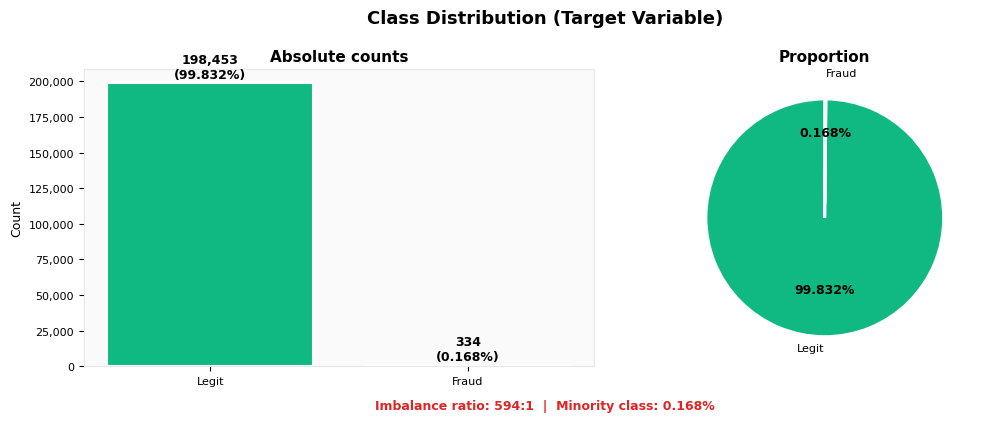

In [7]:
y_tr = train_clean[TARGET]

fig = viz.plot_class_distribution(y_tr)
plt.show()

  Saved → ..\reports\figures\04_feature_histograms_by_class.png


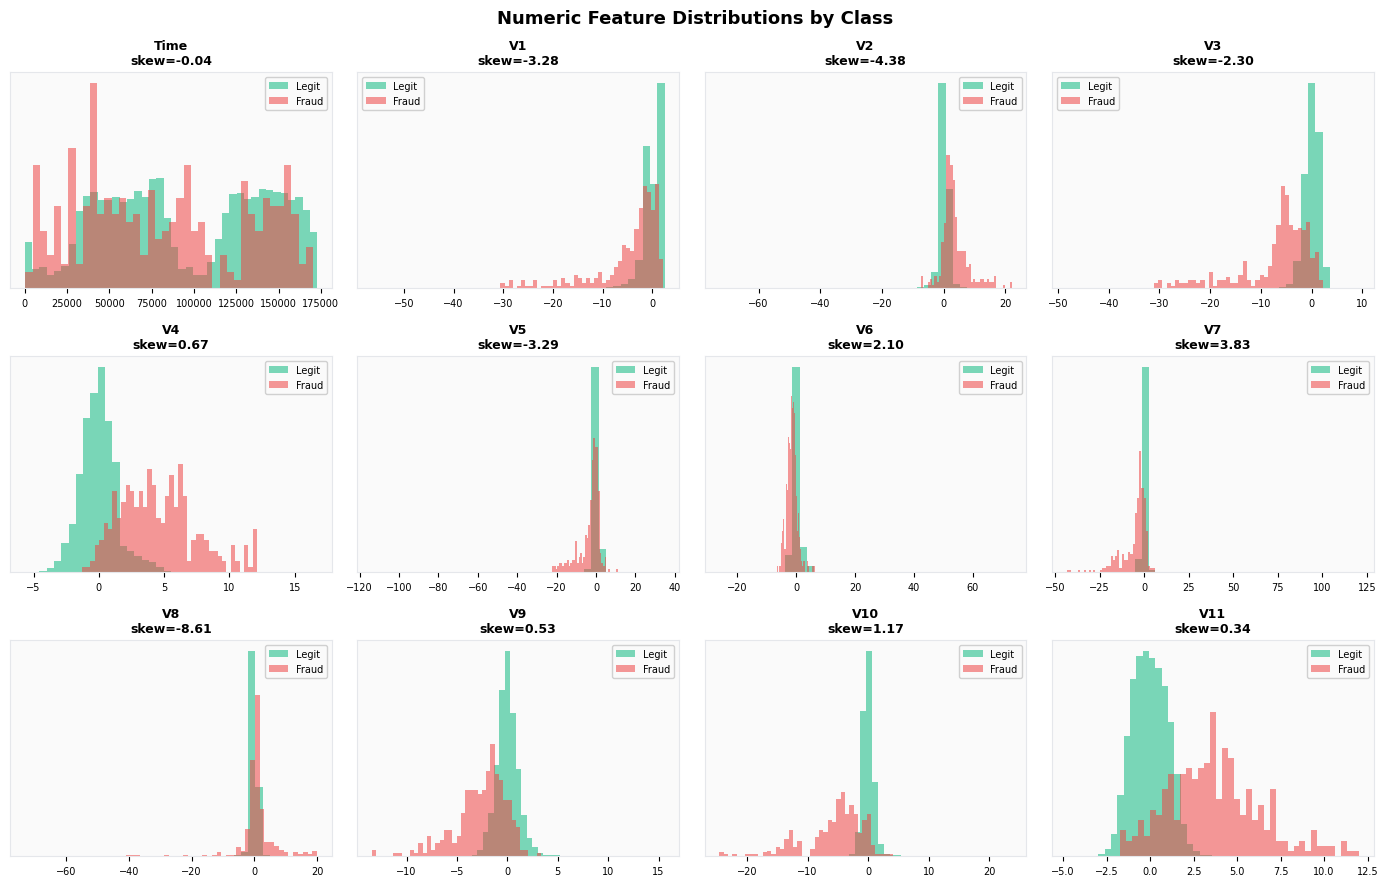

In [8]:
fig = viz.plot_feature_histograms(train_clean, target=TARGET, max_cols=12, ncols=4)
plt.show()

  Saved → ..\reports\figures\08_amount_distribution.png


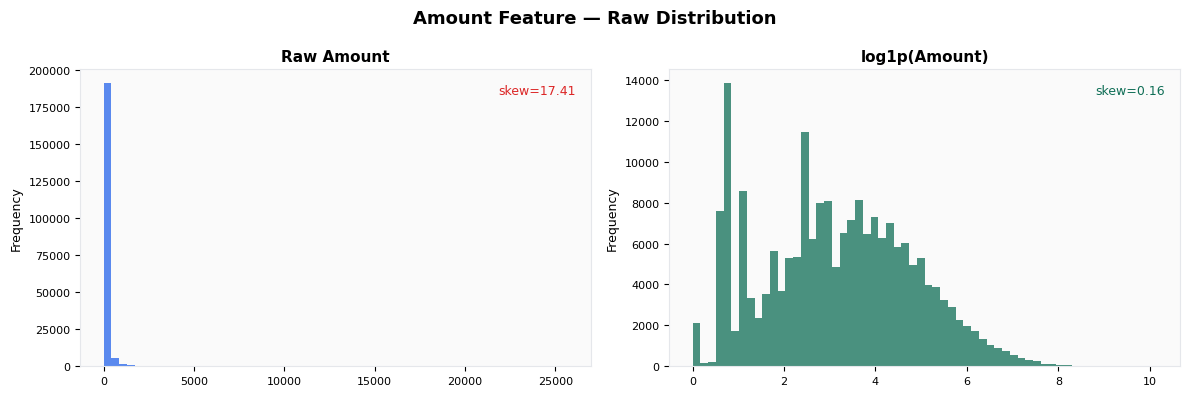

In [9]:
fig = viz.plot_amount_distribution(train_clean)
plt.show()

  Saved → ..\reports\figures\09_time_analysis_full.png


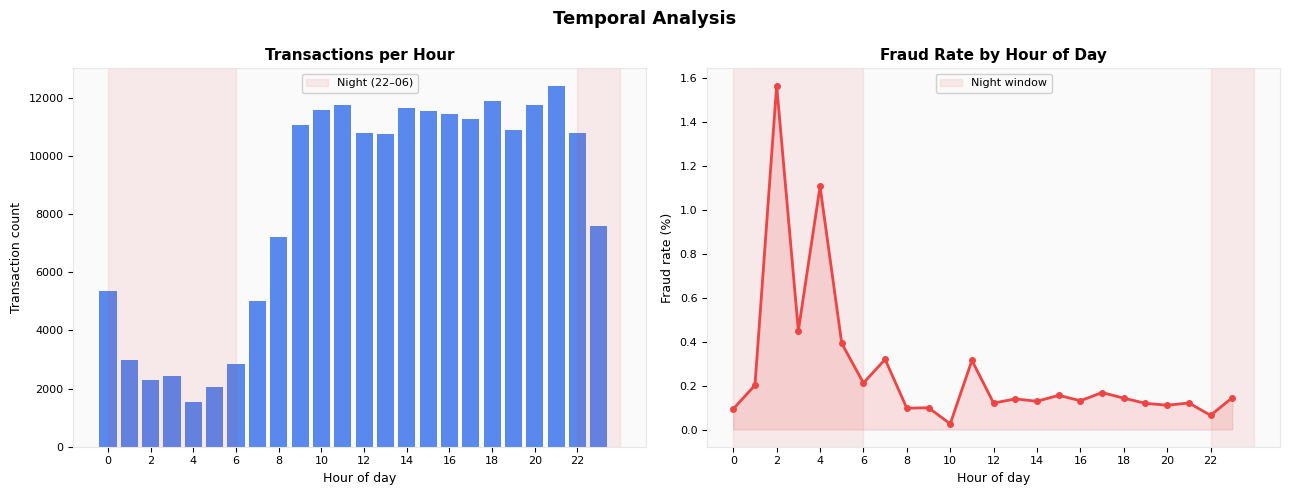

In [10]:
fig = viz.plot_time_analysis(train_clean)
plt.show()

  Saved → ..\reports\figures\07_feature_target_corr.png


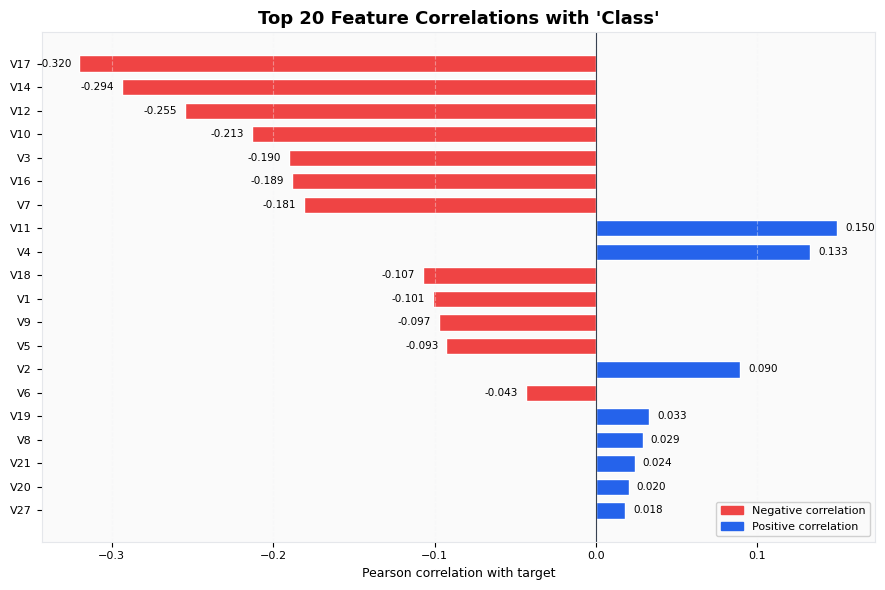

In [11]:
fig = viz.plot_feature_target_correlation(train_clean, target=TARGET, top_n=20)
plt.show()

---
## 5. Feature Engineering — Fit on Train Only


In [12]:
# Separate features from target — feature engineer never sees the target
X_train_clean = train_clean.drop(columns=[TARGET], errors="ignore")
X_val_clean   = val_clean.drop(columns=[TARGET],   errors="ignore")
X_test_clean  = test_clean.drop(columns=[TARGET],  errors="ignore")

fe = FeatureEngineer(config_path=CFG_PATH)

# FIT on training features only
X_train_eng = fe.fit_transform(X_train_clean)

# APPLY to val and test — uses scaler/transformer learned from train
X_val_eng   = fe.transform(X_val_clean)
X_test_eng  = fe.transform(X_test_clean)

print(f"Features before engineering : {X_train_clean.shape[1]}")
print(f"Features after  engineering : {X_train_eng.shape[1]}")
print(f"\nNew engineered columns:")
for col in dict.fromkeys(fe._engineered_cols):
    print(f"  {col}")

2026-06-13 03:32:57 | INFO     | src.features.build_features | === Feature Engineering FIT ===
2026-06-13 03:32:57 | INFO     | src.features.build_features | Time features created: ['hour_of_day', 'day_of_week', 'is_night', 'is_weekend', 'is_business_hr', 'hour_sin', 'hour_cos']
2026-06-13 03:32:57 | INFO     | src.features.build_features | Amount features created: ['log_amount', 'amount_zscore', 'amount_sqrt', 'amount_bin', 'is_high_value']
2026-06-13 03:32:58 | INFO     | src.features.build_features | Skewed columns (|skew|>1): ['V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8', 'V10', 'V12', 'V14', 'V16', 'V17', 'V20', 'V21', 'V23', 'V28', 'Amount', 'is_night', 'amount_zscore', 'amount_sqrt', 'is_high_value']
2026-06-13 03:33:01 | INFO     | src.features.build_features | Scaler (standard) fitted on: ['Amount', 'log_amount', 'amount_zscore']
2026-06-13 03:33:01 | INFO     | src.features.build_features | Feature engineering fitted. Output features: 46
2026-06-13 03:33:01 | INFO     | src.featu

Features before engineering : 35
Features after  engineering : 46

New engineered columns:
  hour_of_day
  day_of_week
  is_night
  is_weekend
  is_business_hr
  hour_sin
  hour_cos
  log_amount
  amount_zscore
  amount_sqrt
  amount_bin
  is_high_value


### 5.1 Spot-check engineered features (train set)

In [13]:
new_cols = [c for c in dict.fromkeys(fe._engineered_cols) if c in X_train_eng.columns]
print("=== New features — first 5 rows ===")
print(X_train_eng[new_cols].head())

print("\n=== Sanity checks ===")
print(f"hour_of_day range : {X_train_eng['hour_of_day'].min():.0f} – {X_train_eng['hour_of_day'].max():.0f}  (expected 0–23)")
print(f"is_night values   : {sorted(X_train_eng['is_night'].unique().tolist())}  (expected [0, 1])")
print(f"log_amount min    : {X_train_eng['log_amount'].min():.4f}  (expected ≥ 0)")
print(f"amount_bin values : {sorted(X_train_eng['amount_bin'].unique().tolist())}  (expected [0,1,2,3,4])")

=== New features — first 5 rows ===
        hour_of_day  day_of_week  is_night  is_weekend  is_business_hr  \
279415      22.0000       1.0000    0.1354           0               0   
277101      22.0000       1.0000    0.1354           0               0   
242608      18.0000       1.0000   -0.0000           0               0   
7790         3.0000       0.0000    0.1354           0               0   
139894      23.0000       0.0000    0.1354           0               0   

        hour_sin  hour_cos  log_amount  amount_zscore  amount_sqrt  \
279415   -0.5000    0.8660      0.7011         0.7309       2.0192   
277101   -0.5000    0.8660      1.9339         2.0265       2.7432   
242608   -1.0000   -0.0000     -0.4575        -0.7337       1.3269   
7790      0.7071    0.7071     -0.0392        -0.3970       1.5768   
139894   -0.2588    0.9659      0.5030         0.3706       1.9010   

        amount_bin  is_high_value  
279415           3        -0.0000  
277101           4        

### 5.2 Skewness — before vs after transformation

In [14]:
print("=== Skewness BEFORE engineering (top 10) ===")
skew_before = (X_train_clean
               .select_dtypes(include=np.number)
               .skew().abs()
               .sort_values(ascending=False)
               .head(10))
print(skew_before.to_string())

print("\n=== Skewness AFTER engineering (top 10) ===")
skew_after = (X_train_eng
              .select_dtypes(include=np.number)
              .skew().abs()
              .sort_values(ascending=False)
              .head(10))
print(skew_after.to_string())

=== Skewness BEFORE engineering (top 10) ===
Amount   17.4081
V28      11.3651
V8        8.6134
V23       5.7282
V2        4.3812
V7        3.8337
V17       3.7066
V5        3.2939
V1        3.2838
V21       2.9103

=== Skewness AFTER engineering (top 10) ===
is_high_value   4.1294
V7              2.8827
V8              2.4361
V21             2.1208
V6              2.0578
is_night        1.5776
V5              1.2978
V10             1.2933
V20             1.1445
V28             0.9893


  Saved → ..\reports\figures\13_skewness.png


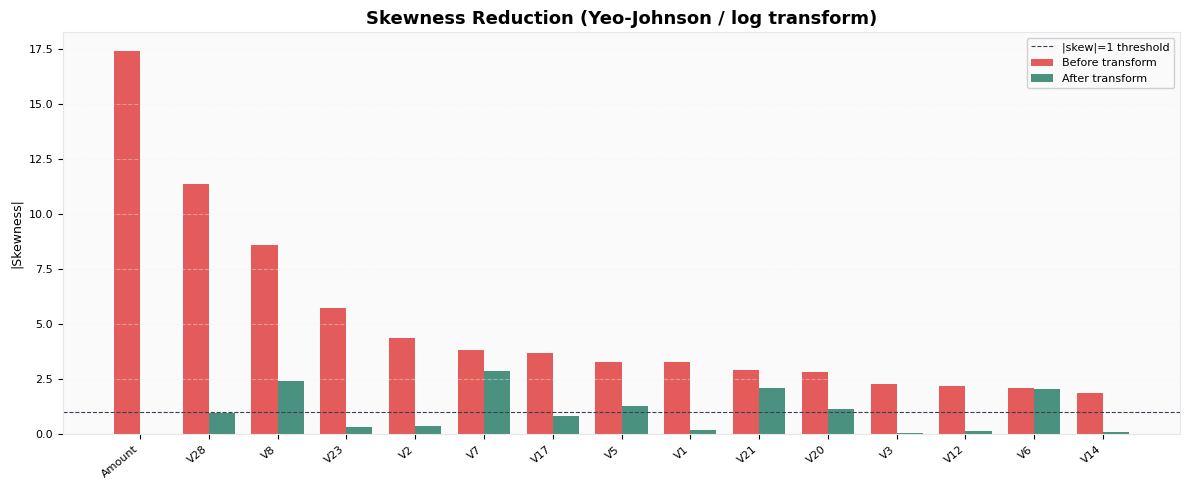

In [15]:
fig = viz.plot_skewness(X_train_clean, X_train_eng)
plt.show()

### 5.3 Save engineering artifacts

In [16]:
fe.save_scaler("../data/processed/scaler.joblib")
fe.save_feature_names("../data/processed/feature_names.json")
print("Scaler saved        → data/processed/scaler.joblib")
print("Feature names saved → data/processed/feature_names.json")
print()
print("These files are needed at inference time to transform new transactions")
print("using the SAME statistics learned from training data.")

2026-06-13 03:34:03 | INFO     | src.features.build_features | Scaler saved → ../data/processed/scaler.joblib
2026-06-13 03:34:03 | INFO     | src.features.build_features | Feature names saved → ../data/processed/feature_names.json


Scaler saved        → data/processed/scaler.joblib
Feature names saved → data/processed/feature_names.json

These files are needed at inference time to transform new transactions
using the SAME statistics learned from training data.


---
## 6. Feature Selection — Fit on Train Only

In [17]:
# Add target back so fit_select() can separate X and y internally
train_eng_df          = X_train_eng.copy()
train_eng_df[TARGET]  = y_train_clean.values

selector = FeatureSelector(config_path=CFG_PATH)

# FIT on training data only
X_train_sel, selected_features = selector.fit_select(train_eng_df)

print(f"\nFeatures into selection : {X_train_eng.shape[1]}")
print(f"Features selected       : {len(selected_features)}")
print(f"\nSelected features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

2026-06-13 03:34:10 | INFO     | src.features.feature_selection | === Feature Selection FIT (training data only) ===
2026-06-13 03:34:10 | INFO     | src.features.feature_selection | Input:  198,787 rows x 46 features
2026-06-13 03:34:10 | INFO     | src.features.feature_selection | Variance filter (threshold=0.01): removed 3 column(s) -> ['is_night', 'is_weekend', 'is_high_value']
2026-06-13 03:34:10 | INFO     | src.features.feature_selection | Correlation filter (threshold=0.95): removed 4 column(s) -> ['log_amount', 'amount_zscore', 'amount_sqrt', 'amount_bin']
2026-06-13 03:34:21 | INFO     | src.features.feature_selection | RFE: selected 20 features from 34 numeric columns
2026-06-13 03:34:36 | INFO     | src.features.feature_selection | Top-5 MI features: [('V17', np.float64(0.00781)), ('V14', np.float64(0.00779)), ('V12', np.float64(0.00731)), ('V10', np.float64(0.00716)), ('V11', np.float64(0.00637))]
2026-06-13 03:34:36 | INFO     | src.features.feature_selection | Output: 25


Features into selection : 46
Features selected       : 25

Selected features:
   1. V2
   2. V3
   3. V4
   4. V5
   5. V6
   6. V7
   7. V9
   8. V10
   9. V11
  10. V12
  11. V14
  12. V15
  13. V16
  14. V17
  15. V18
  16. V20
  17. V21
  18. V26
  19. V27
  20. hour_sin
  21. V20_is_outlier
  22. V6_is_outlier
  23. V27_is_outlier
  24. V2_is_outlier
  25. V8_is_outlier


### 6.1 Apply selected features to val and test — no fitting

In [18]:
# Column selection only — no fitting, no statistics computed on val/test
X_val_sel  = X_val_eng[selected_features]
X_test_sel = X_test_eng[selected_features]

print("=== Shapes after feature selection ===")
print(f"  X_train_sel : {X_train_sel.shape}")
print(f"  X_val_sel   : {X_val_sel.shape}")
print(f"  X_test_sel  : {X_test_sel.shape}")
print()
print("Val and test had ZERO influence on the feature selection fitting.")
print("We simply picked the same columns that were selected from training data.")

=== Shapes after feature selection ===
  X_train_sel : (198787, 25)
  X_val_sel   : (42721, 25)
  X_test_sel  : (42722, 25)

Val and test had ZERO influence on the feature selection fitting.
We simply picked the same columns that were selected from training data.


### 6.2 Investigate removed features

In [19]:
print(f"Removed by variance filter   : {selector.removed_variance_ or 'none'}")
print(f"Removed by correlation filter: {selector.removed_corr_ or 'none'}")
print()

# MI scores for top features
mi_scores = pd.Series(selector.feature_scores_.get("mutual_info", {}))
mi_scores = mi_scores.sort_values(ascending=False)

print("=== Mutual Information scores (top 20) ===")
print(mi_scores.head(20).to_string())
print()

# Validate our feature engineering added value
log_mi  = mi_scores.get("log_amount", 0)
raw_mi  = mi_scores.get("Amount", 0)
night_mi= mi_scores.get("is_night", 0)

print(f"log_amount MI : {log_mi:.5f}")
print(f"Amount (raw)  : {raw_mi:.5f}")
if raw_mi > 0:
    print(f"Ratio         : {log_mi/raw_mi:.1f}x  ← log_amount should be stronger")
else:
    print("Ratio         : N/A (Amount MI = 0)")
print(f"is_night MI   : {night_mi:.5f}  ← domain knowledge encoded as a feature")

Removed by variance filter   : ['is_night', 'is_weekend', 'is_high_value']
Removed by correlation filter: ['log_amount', 'amount_zscore', 'amount_sqrt', 'amount_bin']

=== Mutual Information scores (top 20) ===
V17        0.0078
V14        0.0078
V12        0.0073
V10        0.0072
V11        0.0064
V16        0.0057
V4         0.0048
V3         0.0048
V9         0.0040
V18        0.0039
hour_sin   0.0039
V7         0.0039
V2         0.0031
V27        0.0022
V21        0.0022
V6         0.0020
V5         0.0019
V20        0.0010
V26        0.0003
V15        0.0002

log_amount MI : 0.00000
Amount (raw)  : 0.00000
Ratio         : N/A (Amount MI = 0)
is_night MI   : 0.00000  ← domain knowledge encoded as a feature


  Saved → ..\reports\figures\12_feature_importance.png


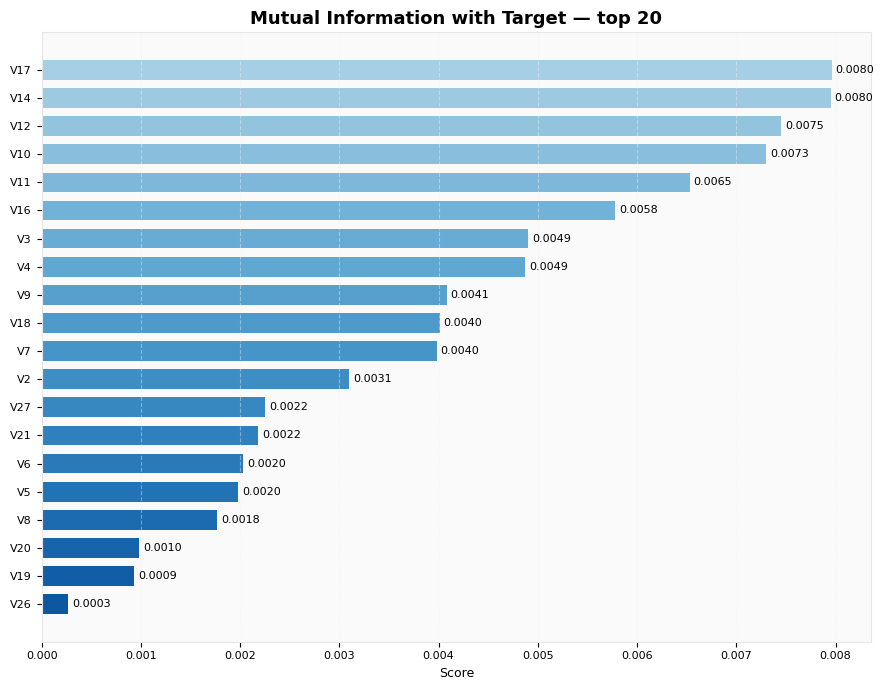

In [51]:
fig = viz.plot_feature_importance(
    selector.feature_scores_.get("mutual_info", {}),
    title="Mutual Information with Target — top 20",
    top_n=20
)
plt.show()

---
## 7. SMOTE — Train Set Only


In [20]:
print("=== Before SMOTE (training fold) ===")
print(y_train_clean.value_counts().to_string())
print(f"Fraud rate: {y_train_clean.mean():.4%}")

# SMOTE on training set ONLY
X_train_bal, y_train_bal = selector._balance(X_train_sel, y_train_clean)

print("\n=== After SMOTE (training fold) ===")
print(y_train_bal.value_counts().to_string())
print(f"Fraud rate: {y_train_bal.mean():.4%}")

2026-06-13 04:31:51 | INFO     | src.features.feature_selection | Before SMOTE: {0: 198453, 1: 334}


=== Before SMOTE (training fold) ===
Class
0    198453
1       334
Fraud rate: 0.1680%


2026-06-13 04:31:53 | INFO     | src.features.feature_selection | After  SMOTE: {0: 198453, 1: 198453}



=== After SMOTE (training fold) ===
Class
0    198453
1    198453
Fraud rate: 50.0000%


  Saved → ..\reports\figures\10_smote_comparison.png


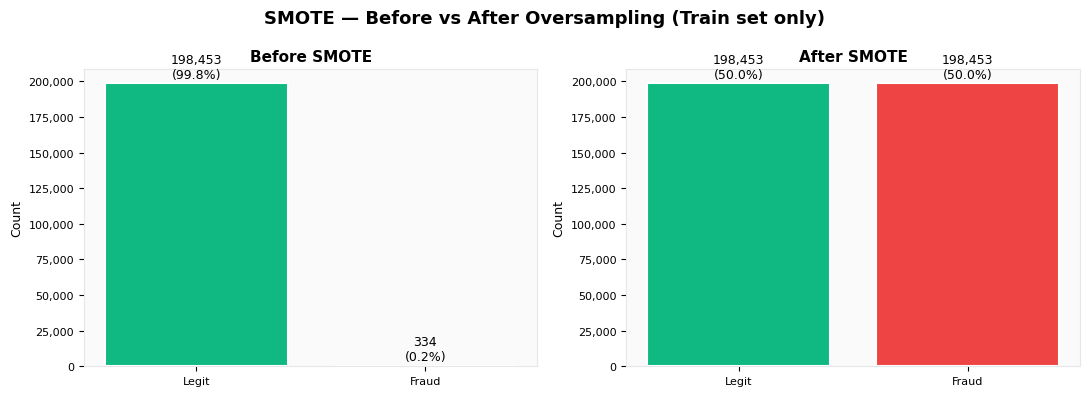

In [21]:
fig = viz.plot_smote_comparison(y_train_clean, pd.Series(y_train_bal))
plt.show()

---
## 8. Final Split Verification

In [23]:
selector.log_summary(
    X_train_bal, X_val_sel, X_test_sel,
    y_train_bal, y_val, y_test
)

print("=== What to verify ===")
print(f"  Train fraud rate : {y_train_bal.mean():.4%}  ← should be ~50% (SMOTE balanced)")
print(f"  Val fraud rate   : {y_val.mean():.4%}  ← should be ~0.173% (natural)")
print(f"  Test fraud rate  : {y_test.mean():.4%}  ← should be ~0.173% (natural)")
print()
print("If val or test fraud rate is 50%: SMOTE was accidentally applied to them.")
print("If val/test rates differ from 0.173%: stratification failed — investigate.")

2026-06-13 04:32:04 | INFO     | src.features.feature_selection | ──────────────────────────────────────────────────────────────
2026-06-13 04:32:04 | INFO     | src.features.feature_selection | SPLIT & BALANCE SUMMARY
2026-06-13 04:32:04 | INFO     | src.features.feature_selection |   Train (balanced) :  396,906 rows | fraud: 198,453 (50.0000%)
2026-06-13 04:32:04 | INFO     | src.features.feature_selection |   Validation       :   42,721 rows | fraud:     74 (0.1732%)
2026-06-13 04:32:04 | INFO     | src.features.feature_selection |   Test             :   42,722 rows | fraud:     74 (0.1732%)
2026-06-13 04:32:04 | INFO     | src.features.feature_selection |   Features selected  : 25
2026-06-13 04:32:04 | INFO     | src.features.feature_selection |   Removed (variance) : ['is_night', 'is_weekend', 'is_high_value']
2026-06-13 04:32:04 | INFO     | src.features.feature_selection |   Removed (corr)     : ['log_amount', 'amount_zscore', 'amount_sqrt', 'amount_bin']
2026-06-13 04:32:04 | I

=== What to verify ===
  Train fraud rate : 50.0000%  ← should be ~50% (SMOTE balanced)
  Val fraud rate   : 0.1732%  ← should be ~0.173% (natural)
  Test fraud rate  : 0.1732%  ← should be ~0.173% (natural)

If val or test fraud rate is 50%: SMOTE was accidentally applied to them.
If val/test rates differ from 0.173%: stratification failed — investigate.


  Saved → ..\reports\figures\11_split_donut.png


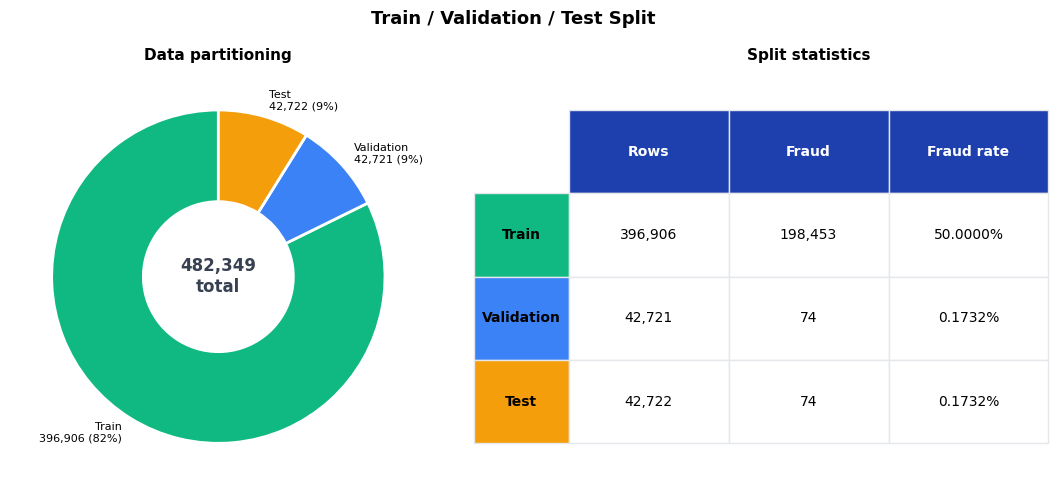

In [24]:
fig = viz.plot_split_donut(
    n_train=len(X_train_bal),
    n_val=len(X_val_sel),
    n_test=len(X_test_sel),
    fraud_train=int(y_train_bal.sum()),
    fraud_val=int(y_val.sum()),
    fraud_test=int(y_test.sum()),
)
plt.show()

---
## 9. Leakage Verification Checklist


In [26]:
print("DATA LEAKAGE VERIFICATION CHECKLIST")
print("=" * 50)

checks = [
    ("Split happened BEFORE any fitting",
     "train_test_split called on raw data in cell 2"),
    ("Preprocessor fitted on train only",
     "preprocessor.fit_transform(train_raw_df)"),
    ("Preprocessor applied to val/test",
     "preprocessor.transform(val/test) — no refitting"),
    ("FeatureEngineer fitted on train only",
     "fe.fit_transform(X_train_clean)"),
    ("FeatureEngineer applied to val/test",
     "fe.transform(X_val/test_clean) — uses train scaler"),
    ("Feature selection fitted on train only",
     "selector.fit_select(train_eng_df)"),
    ("Feature selection applied to val/test",
     "X_val_eng[selected_features] — column selection only"),
    ("SMOTE applied to train only",
     "selector._balance(X_train_sel, y_train)"),
    ("Val/test remain natural distributions",
     f"Val: {y_val.mean():.4%} | Test: {y_test.mean():.4%}"),
]

for check, evidence in checks:
    print(f"  [OK]  {check}")
    print(f"        Evidence: {evidence}")
    print()

DATA LEAKAGE VERIFICATION CHECKLIST
  [OK]  Split happened BEFORE any fitting
        Evidence: train_test_split called on raw data in cell 2

  [OK]  Preprocessor fitted on train only
        Evidence: preprocessor.fit_transform(train_raw_df)

  [OK]  Preprocessor applied to val/test
        Evidence: preprocessor.transform(val/test) — no refitting

  [OK]  FeatureEngineer fitted on train only
        Evidence: fe.fit_transform(X_train_clean)

  [OK]  FeatureEngineer applied to val/test
        Evidence: fe.transform(X_val/test_clean) — uses train scaler

  [OK]  Feature selection fitted on train only
        Evidence: selector.fit_select(train_eng_df)

  [OK]  Feature selection applied to val/test
        Evidence: X_val_eng[selected_features] — column selection only

  [OK]  SMOTE applied to train only
        Evidence: selector._balance(X_train_sel, y_train)

  [OK]  Val/test remain natural distributions
        Evidence: Val: 0.1732% | Test: 0.1732%



---
## 10. Save All Splits — Ready for Model Training


In [27]:
selector.save_results(
    X_train_bal, X_val_sel, X_test_sel,
    y_train_bal, y_val, y_test,
    base_path="../data/processed/"
)
print()
print("Files saved to data/processed/:")
print("  X_train_bal.parquet   ← balanced training features (SMOTE applied)")
print("  X_val.parquet         ← validation features (natural distribution)")
print("  X_test.parquet        ← test features (locked away for final eval)")
print("  y_train_bal.parquet   ← balanced training labels")
print("  y_val.parquet")
print("  y_test.parquet")
print("  selected_features.json ← ordered list of 20 selected feature names")
print("  mi_scores.json         ← mutual information scores per feature")

2026-06-13 04:32:55 | INFO     | src.features.feature_selection | Saved X_train_bal.parquet  shape: (396906, 25)
2026-06-13 04:32:55 | INFO     | src.features.feature_selection | Saved X_val.parquet  shape: (42721, 25)
2026-06-13 04:32:55 | INFO     | src.features.feature_selection | Saved X_test.parquet  shape: (42722, 25)
2026-06-13 04:32:55 | INFO     | src.features.feature_selection | Saved y_train_bal.parquet
2026-06-13 04:32:55 | INFO     | src.features.feature_selection | Saved y_val.parquet
2026-06-13 04:32:55 | INFO     | src.features.feature_selection | Saved y_test.parquet
2026-06-13 04:32:55 | INFO     | src.features.feature_selection | All splits and metadata saved -> E:\Python projects\fraud-detection-system\data\processed



Files saved to data/processed/:
  X_train_bal.parquet   ← balanced training features (SMOTE applied)
  X_val.parquet         ← validation features (natural distribution)
  X_test.parquet        ← test features (locked away for final eval)
  y_train_bal.parquet   ← balanced training labels
  y_val.parquet
  y_test.parquet
  selected_features.json ← ordered list of 20 selected feature names
  mi_scores.json         ← mutual information scores per feature


---
## 11. Final Summary — Ready for Model Training

| Step | Input | Output |
|------|-------|--------|
| Raw data | 284,807 rows × 32 cols | — |
| Split (train) | — | ~198,608 rows |
| After cleaning | ~198,608 rows | ~197,527 rows (dedup) |
| After engineering | 30 features | 39 features |
| After RFE selection | 39 features | 20 features |
| After SMOTE | ~344 fraud rows | ~197,527 fraud rows |
| **Train (final)** | — | **~395,054 rows × 20 features** |
| **Val** | — | **~42,559 rows × 20 features** |
| **Test** | — | **~42,559 rows × 20 features** |

